## Package Installation

In [ ]:
%pip install nltk
%pip install spacy
## the above command for nltk only installs the package partially, so to have all features, nltk.download("all")

In [2]:
import pandas as pd
import nltk
import spacy
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

## Data Importing 

In [3]:
twitter_data=pd.read_csv("https://raw.githubusercontent.com/venkatareddykonasani/Datasets/master/Twitter_Sentiment/Twitter_Sentiment_Data.csv")
twitter_data.sample(10)

,tweet_ID,raw_tweet,sentiment_label
15897,04236cf85a,"yip, that would be a sign that you`ve been on...",negative
25493,b4f519eebf,I kno I kknow ... sigh... been on. but it sux,negative
3376,dddea32d04,just slammed my finger in a car dor FML ow,negative
24769,5eebf03264,happy mothers day x & go the dockers,positive
18027,fd7a68c36f,Sigh,neutral
3427,2ca5660e66,May 10 is Human Kindness Day.,neutral
14846,b1b8c03333,"Every time it rains, I see at least 1 ambulance",negative
654,687ee0bd2d,Wide awake and grouchy as ****.,negative
14665,a910982f47,Latest: Saw Animal Collective in Oakland and t...,positive
2080,46c3d8aa55,yay Happy Mothers Day to me Screw burnt brea...,positive


## A Single function for pre-processing

In [ ]:
contra_Expan_Dict = {"ain`t": "am not","aren`t": "are not","can`t": "cannot","can`t`ve": "cannot have","`cause": "because",
"could`ve": "could have","couldn`t": "could not","couldn`t`ve": "could not have","didn`t": "did not",
"doesn`t": "does not","don`t": "do not","hadn`t": "had not","hadn`t`ve": "had not have","hasn`t": "has not",
"haven`t": "have not","he`d": "he would","he`d`ve": "he would have","he`ll": "he will","he`ll`ve": "he will have",
"he`s": "he is","how`d": "how did","how`d`y": "how do you","how`ll": "how will",
"how`s": "how does","i`d": "i would","i`d`ve": "i would have","i`ll": "i will","i`ll`ve": "i will have","i`m": "i am",
"i`ve": "i have","isn`t": "is not","it`d": "it would","it`d`ve": "it would have","it`ll": "it will","it`ll`ve": "it will have",
"it`s": "it is","let`s": "let us","ma`am": "madam","mayn`t": "may not","might`ve": "might have","mightn`t": "might not",
"mightn`t`ve": "might not have","must`ve": "must have","mustn`t": "must not","mustn`t`ve": "must not have","needn`t": "need not","needn`t`ve": "need not have",
"o`clock": "of the clock","oughtn`t": "ought not","oughtn`t`ve": "ought not have","shan`t": "shall not",
"sha`n`t": "shall not","shan`t`ve": "shall not have","she`d": "she would",
"she`d`ve": "she would have","she`ll": "she will","she`ll`ve": "she will have",
"she`s": "she is","should`ve": "should have","shouldn`t": "should not","shouldn`t`ve": "should not have","so`ve": "so have","so`s": "so is",
"that`d": "that would","that`d`ve": "that would have","that`s": "that is","there`d": "there would","there`d`ve": "there would have","there`s": "there is",
"they`d": "they would","they`d`ve": "they would have","they`ll": "they will","they`ll`ve": "they will have","they`re": "they are","they`ve": "they have",
"to`ve": "to have","wasn`t": "was not"," u ": " you "," ur ": " your "," n ": " and ","won`t": "would not",
"dis": "this","bak": "back","brng": "bring"}

def expanded_form(x):
    if x in contra_Expan_Dict.keys():
        return(contra_Expan_Dict[x])
    else:
        return(x)

from spacy.lang.en.stop_words import STOP_WORDS as spacy_stopwords
spacy_stopwords.update({"would", "rt","like", "ha", "lol", "need", "do"})

import re
def clean_with_re(x):
    x=str(x)
    x=re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'," ", x) #Remove URLs
    x=re.sub(r'[^\w ]+', "", x) # Remove Punctuation-1
    x=re.sub(r"[,!@&\'?\.$%_]"," ", x) # Remove Punctuation-2
    x=re.sub(r"\d+"," ", x) #Remove digits
    return(x)

spacy_model = spacy.load('en_core_web_sm')

def pre_processing(input_data, text_col):
    input_data["text_col_clean"]=input_data[text_col].apply(lambda x:str(x).lower())  # Lowercase Conversion
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[expanded_form(t) for t in str(x).split()])  # Expanding Contractions
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in x if t not in spacy_stopwords ])  # Stopword Removal 
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:clean_with_re(x))  # Cleaning using regex
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:" ".join([t.lemma_ for t in spacy_model(str(x))])) # Lemmatization
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x:[t for t in str(x).split() if t not in spacy_stopwords ])  # Stopword Removal again after lemmatization
    input_data["text_col_clean"]=input_data["text_col_clean"].apply(lambda x: " ".join(x) )  # Joining the list back to string
    print(input_data[[text_col,"text_col_clean"]])

In [5]:
pre_processing(input_data=twitter_data, text_col="raw_tweet")

                                               raw_tweet  \
0                    I`d have responded, if I were going   
1          Sooo SAD I will miss you here in San Diego!!!   
2                              my boss is bullying me...   
3                         what interview! leave me alone   
4       Sons of ****, why couldn`t they put them on t...   
...                                                  ...   
27476   wish we could come see u on Denver  husband l...   
27477   I`ve wondered about rake to.  The client has ...   
27478   Yay good for both of you. Enjoy the break - y...   
27479                         But it was worth it  ****.   
27480     All this flirting going on - The ATG smiles...   

                                          text_col_clean  
0                                              I respond  
1                                sooo sad miss san diego  
2                                           boss bully I  
3                                        in

## WordCloud

Note: you may need to restart the kernel to use updated packages.


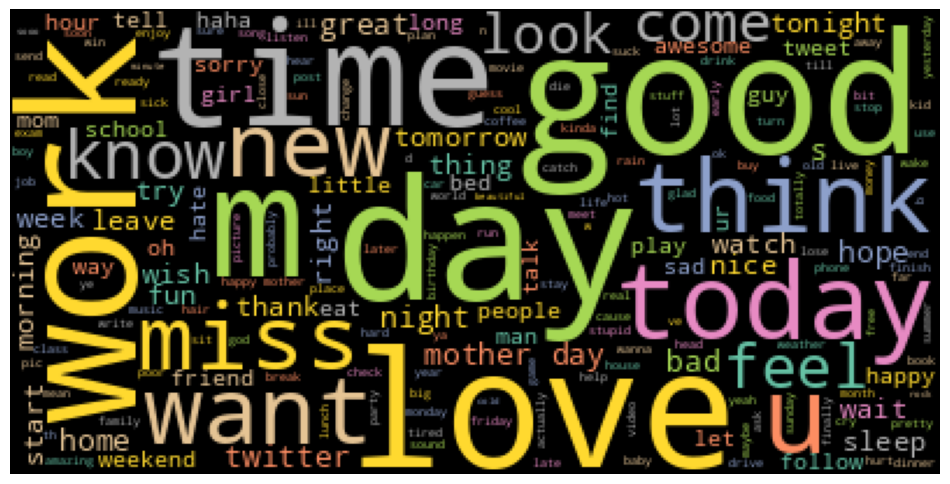

In [9]:
%pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

final_text="".join(twitter_data["text_col_clean"])
len(final_text)

plt.figure(figsize = (12, 12), facecolor = None)
wc=WordCloud(colormap='Set2').generate(final_text)
plt.imshow(wc)
plt.axis("off")
plt.show()

## Document Term Matrix

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

countvec1 = CountVectorizer(min_df= 5)  # keep only words having minimum word freq=5
dtm_v1 = pd.DataFrame(countvec1.fit_transform(twitter_data['text_col_clean']).toarray(), columns=countvec1.get_feature_names_out(), index=None)
print(dtm_v1.shape)
dtm_v1

(27481, 3468)


,aaaah,aah,abandon,ability,abit,able,absolutely,abt,ac,academy,...,yum,yummy,yup,zac,zealand,zero,zombie,zone,zoo,ï½
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27476,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27477,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27478,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27479,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Sentiment Analysis

### Features, Target, Train and Test Data

In [11]:
twitter_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tweet_ID         27481 non-null  str  
 1   raw_tweet        27480 non-null  str  
 2   sentiment_label  27481 non-null  str  
 3   text_col_clean   27481 non-null  str  
dtypes: str(4)
memory usage: 858.9 KB


In [ ]:
twitter_data['sentiment_label'].value_counts()

# we should either ignore neutral class or consider it as negative class or positive class based on the requirement of the problem statement 
# otherwise it may confuse the model

sentiment_label
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [17]:
dtm_v1['sentiment_label']=twitter_data['sentiment_label']

#remove neutrals
dtm_v1=dtm_v1[dtm_v1['sentiment_label'] != "neutral"]
print(dtm_v1['sentiment_label'].value_counts())

dtm_v1.info()

sentiment_label
positive    8582
negative    7781
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 16363 entries, 1 to 27479
Columns: 3469 entries, aaaah to sentiment_label
dtypes: int64(3468), str(1)
memory usage: 433.2 MB


In [18]:
from sklearn.model_selection import train_test_split

X=dtm_v1.drop(['sentiment_label'], axis=1)
y=dtm_v1['sentiment_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=33)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(13090, 3468)
(13090,)
(3273, 3468)
(3273,)


### Naive Bayes Model

In [19]:
from sklearn.naive_bayes import MultinomialNB
senti_model = MultinomialNB()
#Fitting model to our data
senti_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [20]:
print("Train Accuracy", senti_model.score(X_train,y_train))
print("Test Accuracy", senti_model.score(X_test,y_test))

Train Accuracy 0.8888464476699771
Test Accuracy 0.8493736633058356


In [21]:
#Prediction
pred_sentiment=senti_model.predict(X_test)
print(pred_sentiment)

['positive' 'positive' 'positive' ... 'negative' 'positive' 'negative']


### Predicting for new data points

As we cannot analyse sentiment of any new review/comment, so we are creating a new dtm having same number of columns as old

In [22]:
t1 ="Awesome experience. Go for it. It is a great place"
t2 ="Very bad day for me today. I would like to forget it as soon as possible"
tweet_list=[t1,t2]

In [23]:
new_comment= pd.DataFrame({"text":tweet_list})

#Spelling Correction
from textblob import TextBlob
new_comment["text_corrected"]=new_comment["text"].apply(lambda x:"".join(TextBlob(x).correct()))
pre_processing(input_data=new_comment, text_col="text_corrected")

                                      text_corrected  \
0  Awesome experience. To for it. It is a great p...   
1  Very bad day for me today. I would like to for...   

                       text_col_clean  
0      awesome experience great place  
1  bad day today forget soon possible  


In [ ]:
# Creating DTM for new reviews/comments
countvec = CountVectorizer()
dtm_newcomment = pd.DataFrame(countvec.fit_transform(new_comment['text_col_clean']).toarray(), columns=countvec.get_feature_names_out(), index=None)
print("New dtm: \n", dtm_newcomment)

# same vocabulary/columns should be present in both train and newcomment data
dtm_v2=dtm_v1.drop(["sentiment_label"],axis=1)
dtm_newcomment_final=pd.DataFrame(columns=dtm_v2.columns.values)
dtm_newcomment_final=pd.concat([dtm_newcomment_final, dtm_newcomment])  # concat newcomment dtm columns to old dtm columns
dtm_newcomment_final=dtm_newcomment_final.fillna(0)   # filling NaN values with 0
print("Updated new dtm with old dtm columns: \n", dtm_newcomment_final)

New dtm: 
    awesome  bad  day  experience  forget  great  place  possible  soon  today
0        1    0    0           1       0      1      1         0     0      0
1        0    1    1           0       1      0      0         1     1      1
Updated new dtm with old dtm columns: 
   aaaah aah abandon ability abit able absolutely abt ac academy  ... yum  \
0     0   0       0       0    0    0          0   0  0       0  ...   0   
1     0   0       0       0    0    0          0   0  0       0  ...   0   

  yummy yup zac zealand zero zombie zone zoo ï½  
0     0   0   0       0    0      0    0   0  0  
1     0   0   0       0    0      0    0   0  0  

[2 rows x 3468 columns]


In [34]:
print("****Make sure that New DTM and old DTM have same number of columns***")
print("New DTM Shape", dtm_newcomment_final.shape)
print("Overall DTM Shape",dtm_v2.shape)

New_words=[t for t in dtm_newcomment_final.columns.values if t not in dtm_v2.columns.values]
print("Count of new words =>", len(New_words))
print("New words are => ", New_words)

****Make sure that New DTM and old DTM have same number of columns***
New DTM Shape (2, 3468)
Overall DTM Shape (16363, 3468)
Count of new words => 0
New words are =>  []


In [ ]:
# Dataframe to store results
result=pd.DataFrame()
result["text"]=new_comment["text"]
result["Sentiment"] = senti_model.predict(dtm_newcomment_final)  # predicting sentiment for new comments/reviews
print(result)

                                                text Sentiment
0  Awesome experience. Go for it. It is a great p...  positive
1  Very bad day for me today. I would like to for...  negative
